In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, models, layers

In [ ]:
!nvidia-smi

Tue Jun 23 06:12:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                 Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000          15401        359                1  
dreamtensor/fifa-player-performance-analysis                      FIFA Transfer Market Analytics Dataset                   64717  2026-06-11 18:46:20.830000            676         21                1  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset    FIFA World Cup 2026 Player Performance Dataset         4154062  2026-06-10 12:58:47.093000           2428         55          

In [ ]:
!kaggle datasets list -s "plant disease"

ref                                                         title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
vipoooool/new-plant-diseases-dataset                        New Plant Diseases Dataset                    2897709187  2018-11-18 07:09:16.050000         193333       1710  0.75             
turakut/plant-disease-classification                        Plant Disease Classification                      358274  2025-06-22 07:54:27.970000           2930         47  1                
rashikrahmanpritom/plant-disease-recognition-dataset        Plant disease recognition dataset             1339624018  2021-07-04 12:32:46.580000          30523        228  0.75             
sadmansakibmahi/plant-disease-expert              

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 179MB/s]



In [ ]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
import os
print(os.listdir())

['.config', 'plantdisease.zip', 'plantvillage-dataset.zip', 'PlantVillage', 'kaggle.json', 'plantvillage', 'sample_data']


In [ ]:
classes = os.listdir("PlantVillage")
print(len(classes))

15


In [ ]:
print(classes[:5])

['Pepper__bell___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___Late_blight', 'Tomato_Early_blight']


In [ ]:
classes

['Pepper__bell___healthy',
 'Tomato_Leaf_Mold',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Potato___Late_blight',
 'Tomato_Early_blight',
 'Tomato_Bacterial_spot',
 'Potato___healthy',
 'Tomato_Septoria_leaf_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato__Target_Spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato_healthy',
 'Potato___Early_blight',
 'Tomato_Late_blight',
 'Pepper__bell___Bacterial_spot']

In [ ]:
for ch in classes:
  print(ch, len(os.listdir(f"PlantVillage/{ch}")))

Pepper__bell___healthy 1478
Tomato_Leaf_Mold 952
Tomato__Tomato_YellowLeaf__Curl_Virus 3209
Potato___Late_blight 1000
Tomato_Early_blight 1000
Tomato_Bacterial_spot 2127
Potato___healthy 152
Tomato_Septoria_leaf_spot 1771
Tomato__Tomato_mosaic_virus 373
Tomato__Target_Spot 1404
Tomato_Spider_mites_Two_spotted_spider_mite 1676
Tomato_healthy 1591
Potato___Early_blight 1000
Tomato_Late_blight 1909
Pepper__bell___Bacterial_spot 997


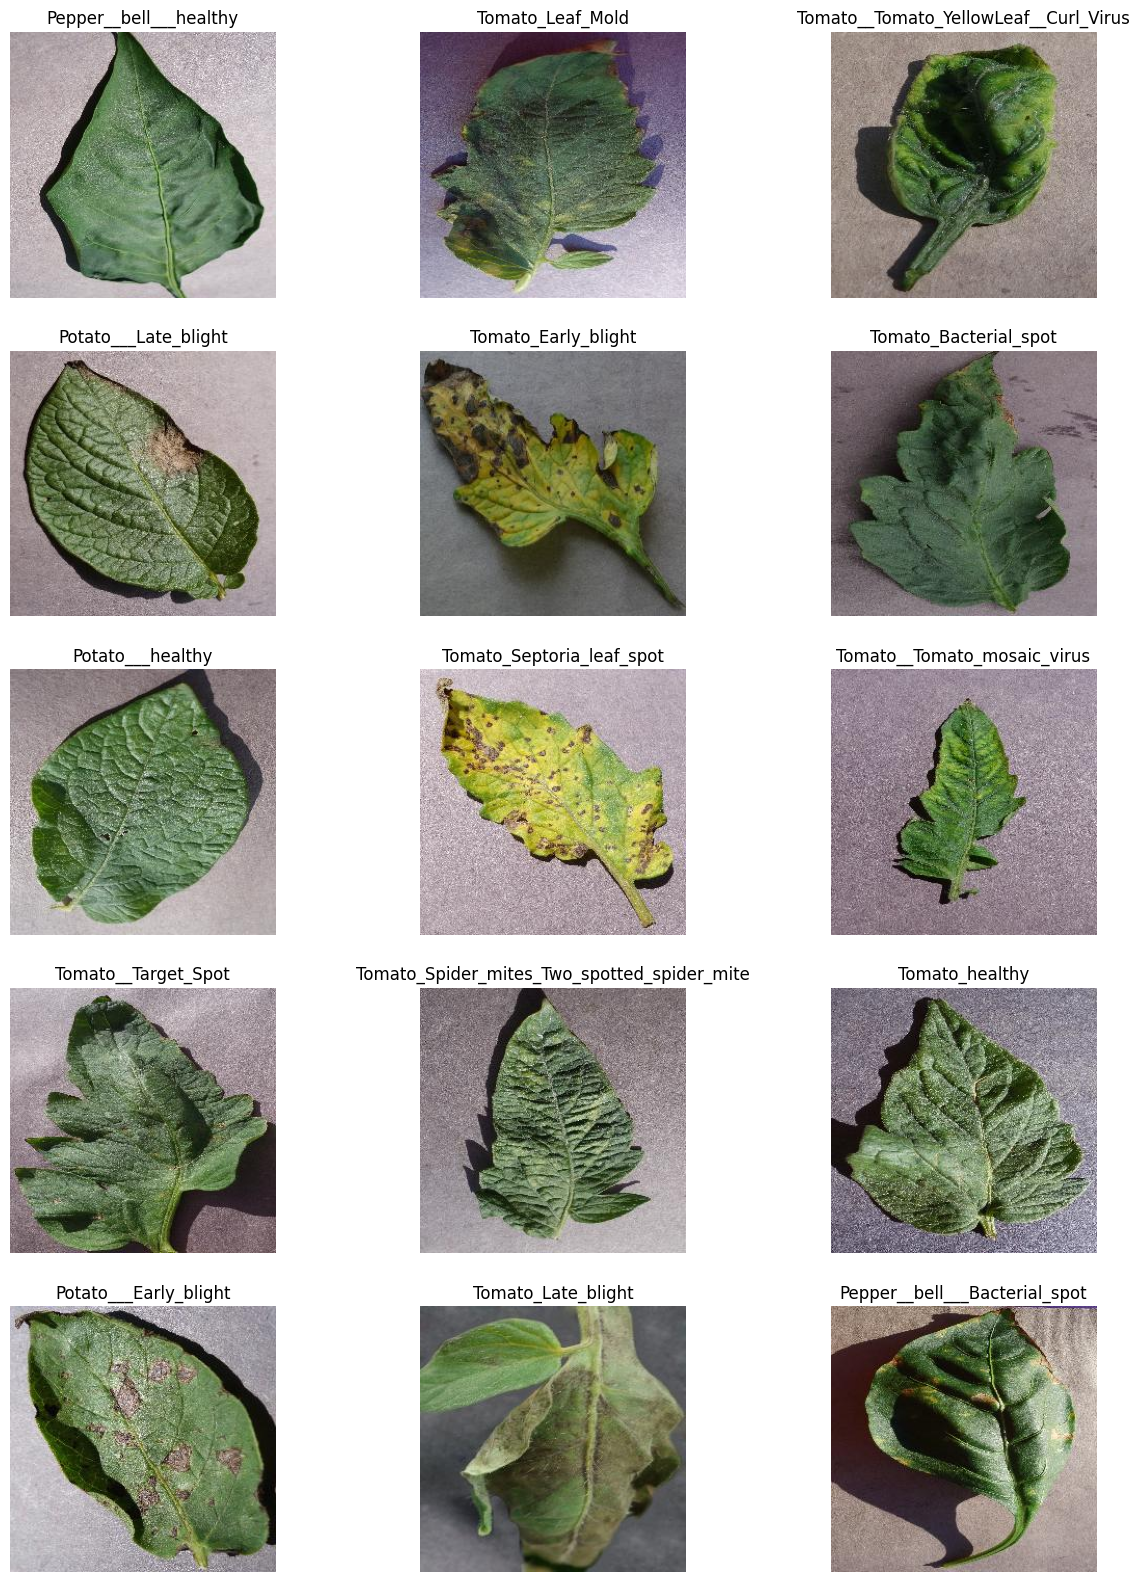

In [ ]:
from PIL import Image

plt.figure(figsize = (15,20))

for i, cls in enumerate(classes):
  img_name = os.listdir(f"PlantVillage/{cls}")[0]
  img_path = f"PlantVillage/{cls}/{img_name}"

  img = Image.open(img_path)
  plt.subplot(5 ,3, i+1)
  plt.imshow(img)
  plt.title(cls)
  plt.axis("off")
plt.show()




In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "PlantVillage",
    labels = "inferred",
    label_mode = 'int',
    image_size = (224, 224),
    batch_size= 32,
    seed = 42,
    validation_split = 0.2,
    subset = "training"
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "PlantVillage",
    labels = "inferred",
    label_mode = 'int',
    image_size = (224, 224),
    batch_size= 32,
    seed = 42,
    validation_split = 0.2,
    subset = "validation"
)


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(15, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - accuracy: 0.7663 - loss: 0.7317 - val_accuracy: 0.8725 - val_loss: 0.3764
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.8732 - loss: 0.3871 - val_accuracy: 0.8941 - val_loss: 0.3023
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8995 - loss: 0.2969 - val_accuracy: 0.8965 - val_loss: 0.3092
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9143 - loss: 0.2507 - val_accuracy: 0.9089 - val_loss: 0.2543
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9224 - loss: 0.2244 - val_accuracy: 0.9150 - val_loss: 0.2402
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.9350 - loss: 0.1923 - val_accuracy: 0.9196 - val_loss: 0.2266
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9382 - loss: 0.1780 - val_accuracy: 0.9217 - val_loss: 0.2265
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9449 - loss: 0.1568 - 

In [ ]:
y_true = []
y_pred = []

for images, labels in valid_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

In [ ]:
print(y_true[20:30])
print(y_pred[20:30])

[np.int32(2), np.int32(9), np.int32(10), np.int32(6), np.int32(10), np.int32(11), np.int32(1), np.int32(0), np.int32(12), np.int32(6)]
[np.int64(2), np.int64(9), np.int64(10), np.int64(6), np.int64(10), np.int64(11), np.int64(1), np.int64(0), np.int64(12), np.int64(7)]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names = train_ds.class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.96      0.97       200
                     Pepper__bell___healthy       0.98      0.98      0.98       302
                      Potato___Early_blight       1.00      0.98      0.99       189
                       Potato___Late_blight       0.95      0.97      0.96       188
                           Potato___healthy       0.96      0.87      0.92        31
                      Tomato_Bacterial_spot       0.97      0.89      0.93       441
                        Tomato_Early_blight       0.80      0.70      0.75       191
                         Tomato_Late_blight       0.91      0.93      0.92       341
                           Tomato_Leaf_Mold       0.87      0.89      0.88       185
                  Tomato_Septoria_leaf_spot       0.88      0.89      0.88       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.90      0.92

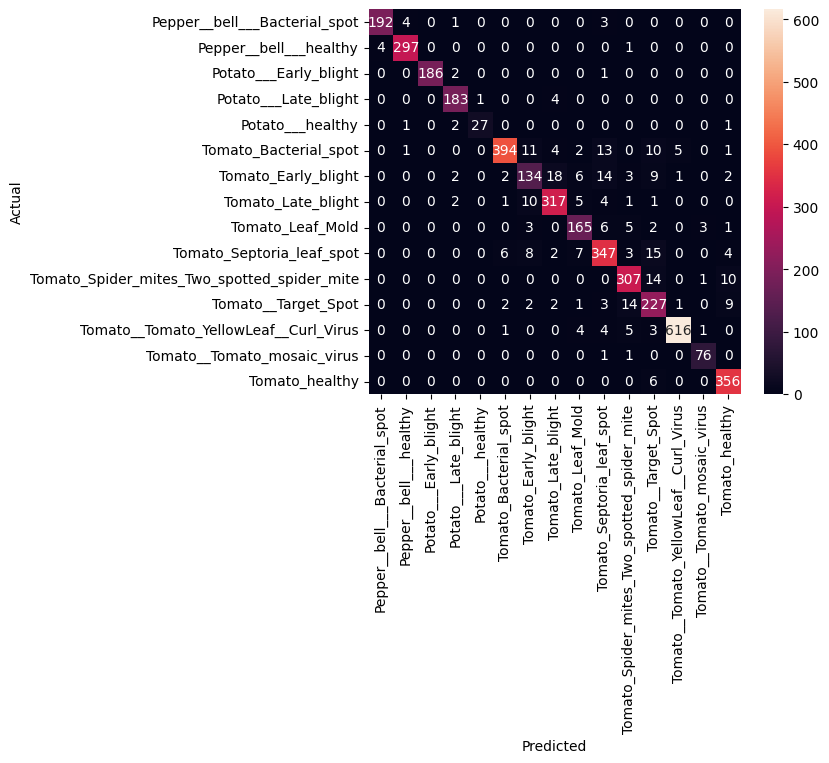

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=train_ds.class_names,

            yticklabels=train_ds.class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.save("plant_disease_mobilenet.keras")

In [ ]:
from google.colab import files

files.download("plant_disease_mobilenet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

size_mb = os.path.getsize("plant_disease_mobilenet.keras") / (1024 * 1024)
print(f"{size_mb:.2f} MB")

11.08 MB
